In [2]:
%load_ext autoreload
%autoreload 2


In [3]:
import image_utils

In [15]:
import torchvision.transforms as transforms
import numpy as np
totensor = transforms.ToTensor()
normalize = transforms.Normalize([0.5], [0.5])

  0%|          | 0/5 [00:00<?, ?it/s]

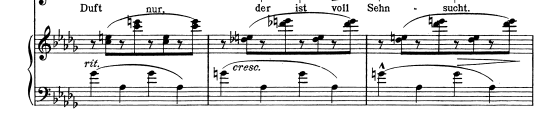

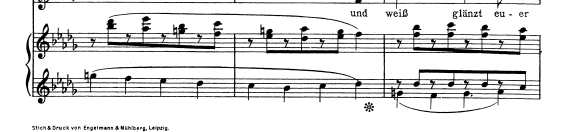

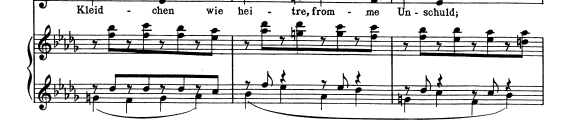

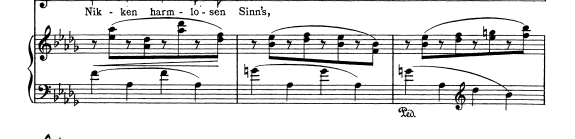

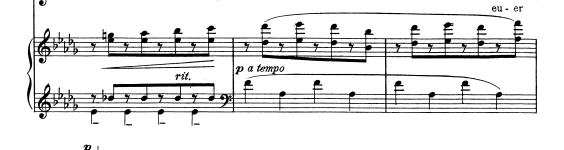

100%|██████████| 5/5 [00:00<00:00, 242.93it/s]


In [5]:
from pathlib import Path
import PIL
from tqdm import tqdm

image_path_list = list(Path("/home/sake/userdata/olimpic_dataset_yolo/olimpic-1.0-scanned/").rglob("*.png"))

for image_path in tqdm(image_path_list[:5]):
  img = PIL.Image.open(image_path).convert("L")
  img.show()


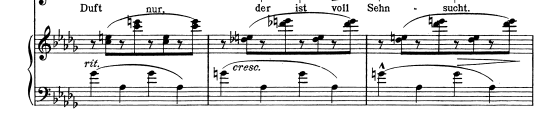

In [6]:
img = PIL.Image.open(image_path_list[0]).convert("L")
img.show()


In [19]:
totensor(img).max(), totensor(img).min()

(tensor(1.), tensor(0.))

In [21]:
normalize(totensor(img)).max(), normalize(totensor(img)).min()

(tensor(1.), tensor(-1.))

In [22]:
totensor(img).shape

torch.Size([1, 140, 560])

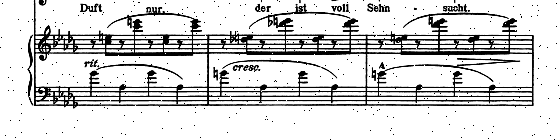

In [23]:
gpn = image_utils.random_global_pixel_negation(normalize(totensor(img)).squeeze(0), 0.01)
PIL.Image.fromarray(gpn.cpu().numpy()*255).show()

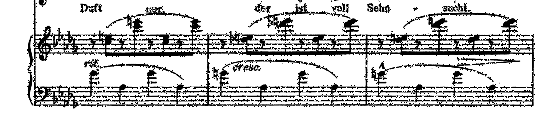

In [30]:
lpn = image_utils.random_local_pixel_negation(normalize(totensor(img)).squeeze(0), 0.2)
PIL.Image.fromarray(lpn.cpu().numpy()*255).show()

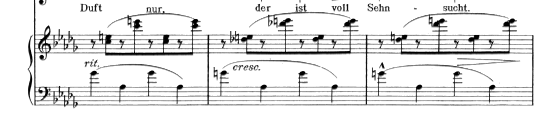

In [47]:
ed = image_utils.random_erosion_dilatation(totensor(img).squeeze(0))
PIL.Image.fromarray(ed.cpu().numpy()*255).show()

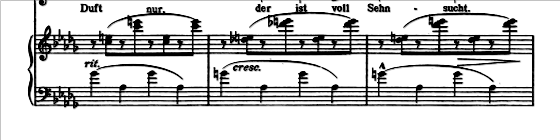

In [50]:
ed = image_utils.random_erosion_dilatation(totensor(img).squeeze(0))
PIL.Image.fromarray(ed.cpu().numpy()*255).show()

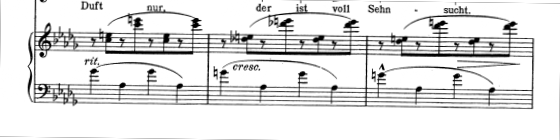

In [51]:
r = image_utils.random_rotate(totensor(img).squeeze(0), 1.)
PIL.Image.fromarray(r.cpu().numpy()*255).show()


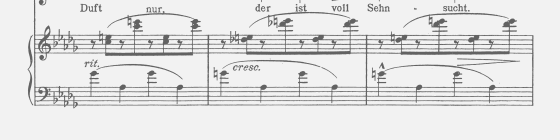

In [63]:
ac = image_utils.random_adjust_contrast(totensor(img).squeeze(0), -1., 1.)
PIL.Image.fromarray(ac.cpu().numpy()*255).show()


In [18]:
ac.shape

torch.Size([140, 560])

In [70]:
normalize(ac.unsqueeze(0)).shape

torch.Size([1, 140, 560])

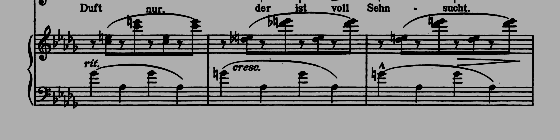

In [69]:
ab = image_utils.random_adjust_brightness(normalize(totensor(img)).squeeze(0), -0.5, 0.2)
PIL.Image.fromarray(ab.cpu().numpy()*255).show()

In [74]:
token_path = Path("/home/sake/userdata/olimpic_dataset_yolo/olimpic-1.0-synthetic/samples/5069058/image_tokens/unirqvae_f16_c1024_k4/yolo_shifted_augmented/p1-s1_yolo_resized.pt")

In [75]:
import torch
token = torch.load(token_path)
token.shape


/tmp/ipykernel_1367990/3235603381.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  token = torch.load(token_path)


torch.Size([6, 8, 4, 9, 33, 4])

In [76]:
token.dtype

torch.int64

In [77]:
token_paths = list(Path("/home/sake/userdata/olimpic_dataset_yolo/olimpic-1.0-scanned/").rglob("*.pt"))
len(token_paths)

2931

In [78]:
a = torch.load(token_paths[0])
a.shape, a.dtype


/tmp/ipykernel_1367990/1084530495.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  a = torch.load(token_paths[0])


(torch.Size([8, 4, 8, 34, 4]), torch.int64)

In [79]:
for token_path in tqdm(token_paths):
  token = torch.load(token_path)
  token = token.to(torch.int16).cpu()
  torch.save(token, token_path)

  0%|          | 0/2931 [00:00<?, ?it/s]/tmp/ipykernel_1367990/2247286842.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  token = torch.load(token_path)
100%|██████████|